# **Import Package**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.diagnostic import linear_reset, het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

# **Telco dataset (load and prepare)**

In [ ]:
# Load the Telco Customer Churn dataset
df = pd.read_csv("/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn 2.csv")

# Remove customerID because it is only an identifier
df = df.drop(columns=["customerID"])

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remove rows with missing values
df = df.dropna()

# Convert Churn from Yes/No to 1/0
y = df["Churn"].map({"No": 0, "Yes": 1})

# Create predictor variables
X = df.drop(columns=["Churn"])

# Convert categorical variables to numeric dummy variables
X = pd.get_dummies(X, drop_first=True, dtype=float)

# **Split/Scale Data**

In [ ]:
# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale predictors
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Put scaled values back into DataFrames so feature names are preserved
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

# **Fit Linear Regression Model**

In [ ]:
# Fit multiple linear regression
lr_model = LinearRegression()

lr_model.fit(
    X_train_scaled_df,
    y_train
)

# Make predictions
lr_pred = lr_model.predict(X_test_scaled_df)

# Model performance
mse = mean_squared_error(y_test, lr_pred)
r2 = r2_score(y_test, lr_pred)

print(f"MSE: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

MSE: 0.1445
R-squared: 0.2595


# **Assumption Testing**

In [ ]:
# Create statsmodels version of the regression model
X_train_sm = sm.add_constant(
    X_train_scaled_df,
    has_constant="add"
)

ols_model = sm.OLS(
    y_train.astype(float),
    X_train_sm
).fit()

# Save predicted values and residuals
fitted_values = ols_model.fittedvalues
residuals = ols_model.resid

# **Model Performance**

In [ ]:
# Model Performance

# Make predictions on the test data
lr_pred = lr_model.predict(X_test_scaled_df)

# Regression performance
mse = mean_squared_error(y_test, lr_pred)
r2 = r2_score(y_test, lr_pred)

# Convert predictions to churn / no churn using 0.50 cutoff
lr_class = (lr_pred >= 0.50).astype(int)

# Classification-style performance
accuracy = accuracy_score(y_test, lr_class)
precision = precision_score(y_test, lr_class, zero_division=0)
recall = recall_score(y_test, lr_class, zero_division=0)
f1 = f1_score(y_test, lr_class, zero_division=0)

print(f"MSE: {mse:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"Accuracy: {accuracy * 100:.1f}%")
print(f"Precision: {precision * 100:.1f}%")
print(f"Recall: {recall * 100:.1f}%")
print(f"F1 Score: {f1:.3f}")

MSE: 0.1445
R-squared: 0.2595
Accuracy: 79.5%
Precision: 63.8%
Recall: 53.2%
F1 Score: 0.580


In [ ]:
# Model Performance
MSE: **0.1445**
R-squared: **0.2595**
Accuracy: **79.5%**
Precision: **63.8%**
Recall: **53.2%**
F1 Score: **0.580**

In [ ]:
# Coefficient Interpretation

lr_coef_model = LinearRegression()
lr_coef_model.fit(X_train, y_train)

coef_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_coef_model.coef_
})

coef_table = coef_table.sort_values(
    "Coefficient",
    ascending=False
)

display(coef_table)

,Feature,Coefficient
10,InternetService_Fiber optic,0.322161
21,StreamingTV_Yes,0.112484
23,StreamingMovies_Yes,0.111554
9,MultipleLines_Yes,0.086748
28,PaymentMethod_Electronic check,0.075946
0,SeniorCitizen,0.042447
7,PhoneService_Yes,0.041050
26,PaperlessBilling_Yes,0.039348
17,DeviceProtection_Yes,0.034363
29,PaymentMethod_Mailed check,0.008805


In [ ]:
# Coefficient Interpretation

InternetService_Fiber optic had the largest positive coefficient (**0.322**), indicating higher predicted churn.

PaymentMethod_Electronic check also increased predicted churn (**0.076**).

Contract_One year had a negative coefficient (**-0.117**), indicating lower predicted churn.

Because multicollinearity was present, individual coefficient estimates should be interpreted cautiously.

SyntaxError: invalid syntax (228902644.py, line 3)

# **ASSUMPTION 1: Linearity**

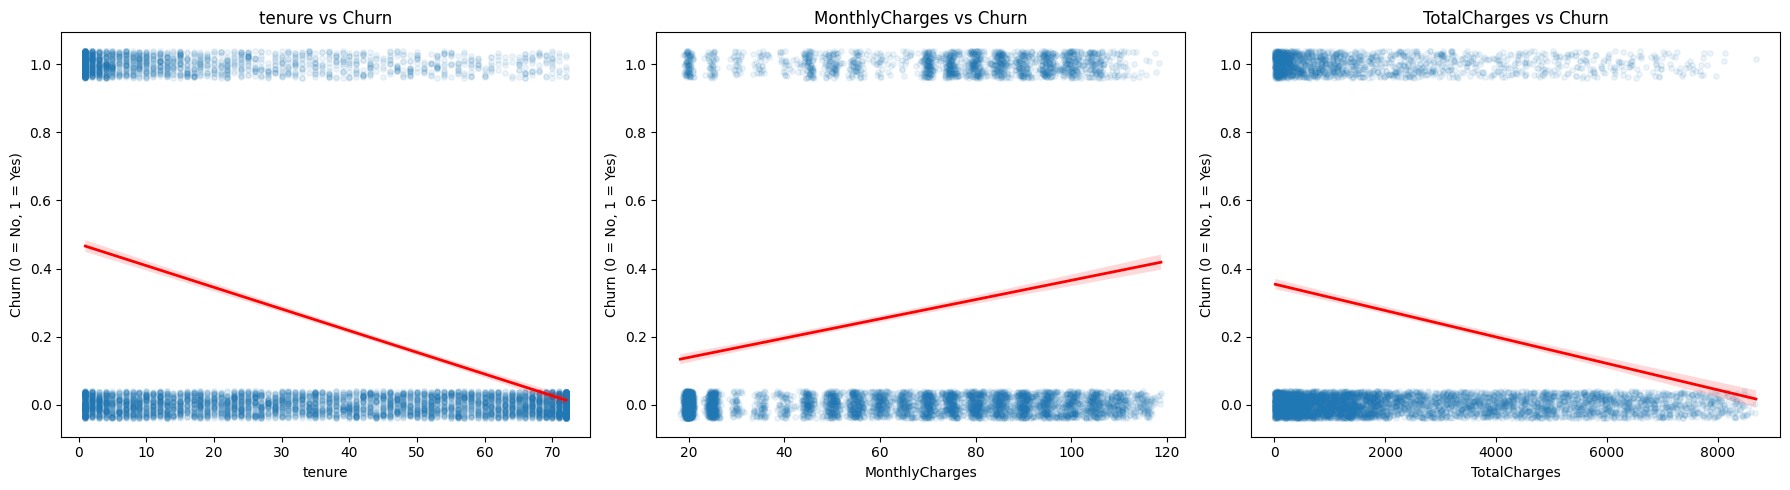

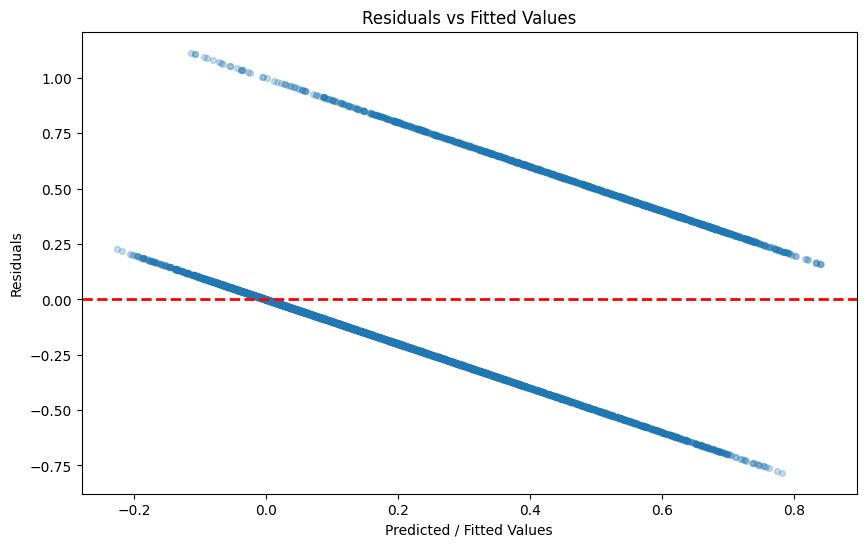

RESET p-value: 0.000000


In [ ]:
# Assumption 1: Linearity

# 1. Scatter plots for continuous predictors vs. churn
continuous_features = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for feature, ax in zip(continuous_features, axes):
    sns.regplot(
        x=df[feature],
        y=y,
        y_jitter=0.04,
        scatter_kws={"alpha": 0.08, "s": 15},
        line_kws={"color": "red", "linewidth": 2},
        ax=ax
    )

    ax.set_title(f"{feature} vs Churn")
    ax.set_ylabel("Churn (0 = No, 1 = Yes)")

plt.tight_layout()
plt.show()


# 2. Residuals vs fitted values
plt.figure(figsize=(10, 6))

plt.scatter(
    fitted_values,
    residuals,
    alpha=0.25,
    s=18
)

plt.axhline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted / Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()


# 3. Ramsey RESET test
reset_result = linear_reset(
    ols_model,
    power=2,
    use_f=True
)

reset_p = float(reset_result.pvalue)

print(f"RESET p-value: {reset_p:.6f}")

In [ ]:
# Linearity assumption is not confirmed
RESET p-value < 0.001.
Residuals show a clear pattern instead of random scatter.

# **ASSUMPTION 2: Independent Observations**

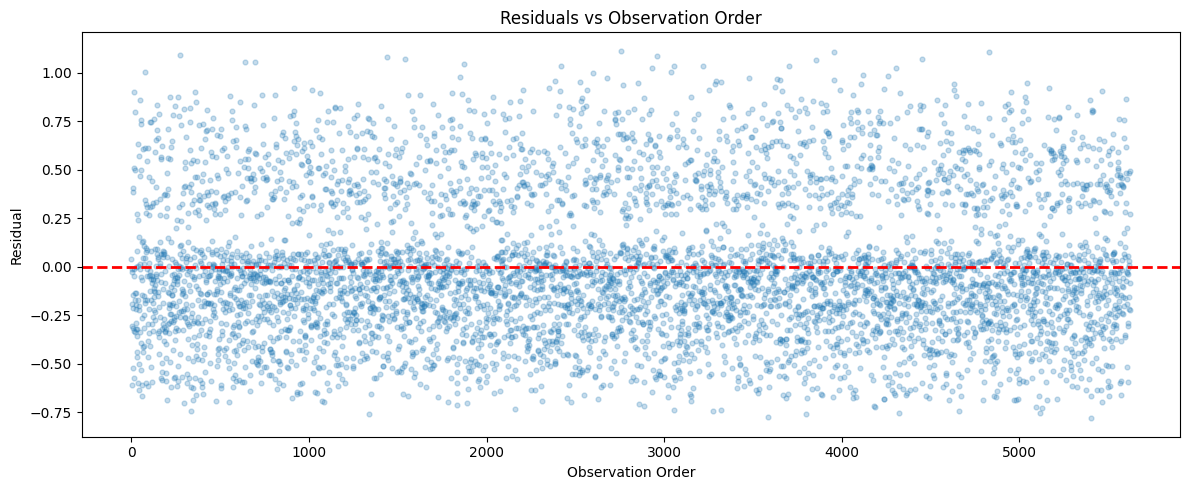

Durbin-Watson statistic: 1.960


In [ ]:
# Assumption 2: Independent Observations

# 1. Plot residuals in observation order
plt.figure(figsize=(12, 5))

plt.scatter(
    np.arange(len(residuals)),
    residuals,
    alpha=0.25,
    s=12
)

plt.axhline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Observation Order")
plt.ylabel("Residual")
plt.title("Residuals vs Observation Order")

plt.tight_layout()
plt.show()


# 2. Durbin-Watson test
dw_stat = durbin_watson(residuals)

print(f"Durbin-Watson statistic: {dw_stat:.3f}")

In [ ]:
# Independence assumption is confirmed
Residuals plotted are randomly scattered with no obvious trend or repeating pattern.
Durbin-Watson statistic was **1.960**, which is very close to 2 and indicates little evidence of autocorrelation among the residuals.

# **ASSUMPTION 3: Homoscedasticity**

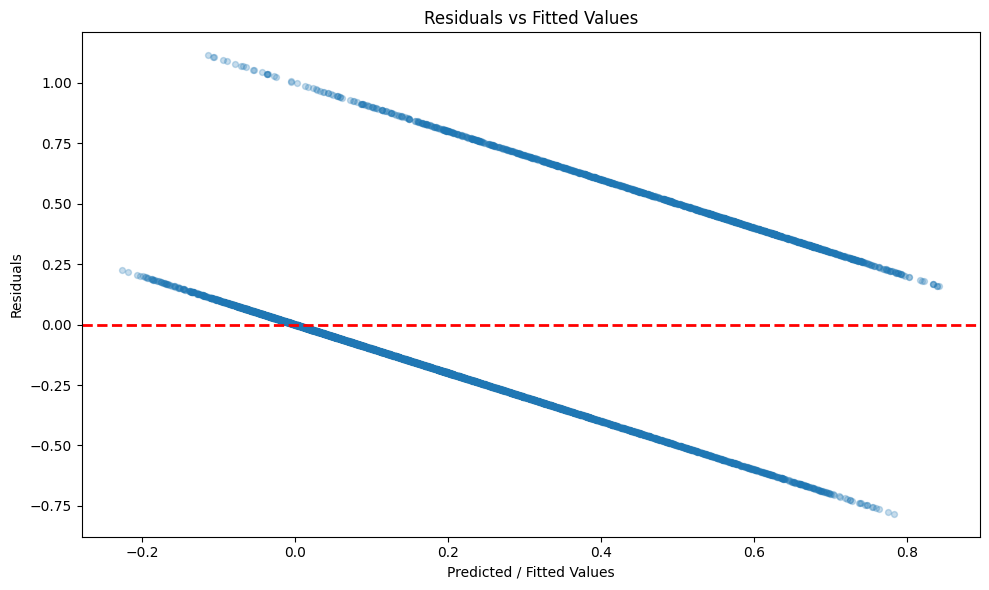

Breusch-Pagan LM statistic: 1096.296
LM p-value: 0.000000
F statistic: 58.951
F-test p-value: 0.000000


In [ ]:
# Assumption 3: Homoscedasticity

# 1. Residuals vs fitted values
plt.figure(figsize=(10, 6))

plt.scatter(
    fitted_values,
    residuals,
    alpha=0.25,
    s=18
)

plt.axhline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted / Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.tight_layout()
plt.show()


# 2. Breusch-Pagan test
bp_test = het_breuschpagan(
    residuals,
    ols_model.model.exog
)

bp_lm, bp_lm_p, bp_f, bp_f_p = bp_test

print(f"Breusch-Pagan LM statistic: {bp_lm:.3f}")
print(f"LM p-value: {bp_lm_p:.6f}")
print(f"F statistic: {bp_f:.3f}")
print(f"F-test p-value: {bp_f_p:.6f}")

In [ ]:
# Homoscedasticity assumption is not confirmed
Strong structured pattern in plot rather than constant/even residuals spread across predicted values.
Both the LM and F-test p-values < 0.001

# **ASSUMPTION 4: Normality of Residuals**

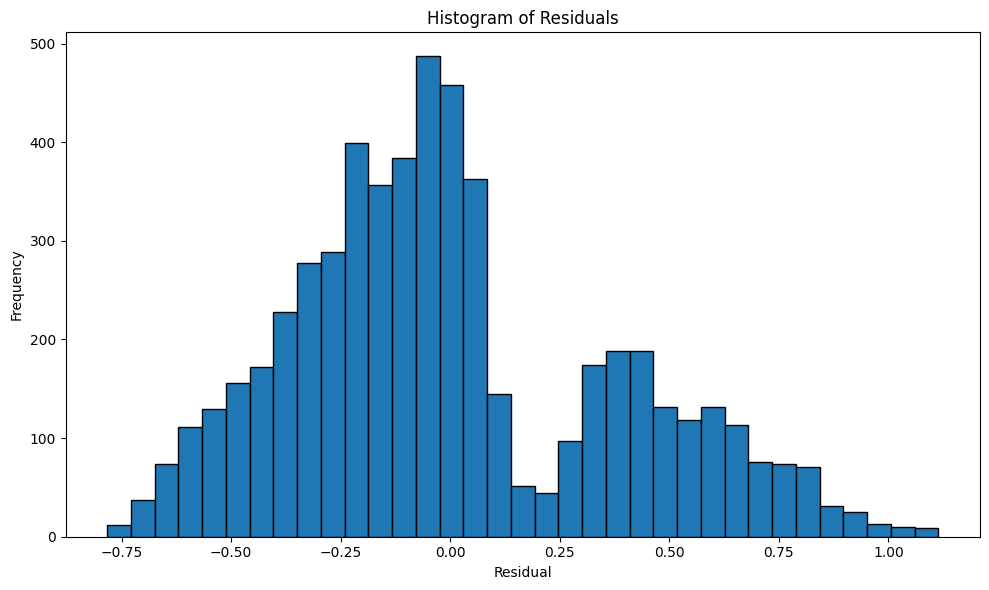

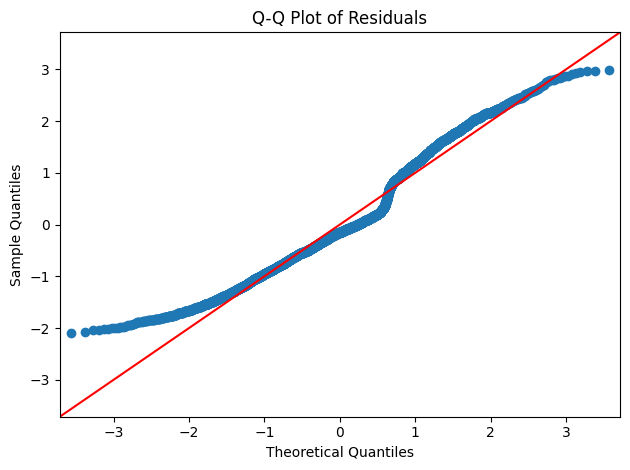

Jarque-Bera statistic: 300.538
p-value: 0.000000
Skewness: 0.545
Kurtosis: 2.693


In [ ]:
# Assumption 4: Normality of Residuals

# 1. Histogram of residuals
plt.figure(figsize=(10, 6))

plt.hist(
    residuals,
    bins=35,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

plt.tight_layout()
plt.show()


# 2. Q-Q plot
sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()


# 3. Jarque-Bera test
jb_stat, jb_p, skew, kurtosis = jarque_bera(residuals)

print(f"Jarque-Bera statistic: {jb_stat:.3f}")
print(f"p-value: {jb_p:.6f}")
print(f"Skewness: {skew:.3f}")
print(f"Kurtosis: {kurtosis:.3f}")

In [ ]:
# Normality of residuals assumption is not confirmed
p-value < 0.001
No normal, bell-shaped distribution, indicating a non-normal distribution.

# **ASSUMPTION 5: No Multicollinearity**

In [ ]:
# Assumption 5: No Multicollinearity
# Clean redundant dummy variables before calculating VIF

X_vif = X_train.astype(float).copy()

# These variables repeat information already contained in InternetService
internet_redundant = [
    "OnlineSecurity_No internet service",
    "OnlineBackup_No internet service",
    "DeviceProtection_No internet service",
    "TechSupport_No internet service",
    "StreamingTV_No internet service",
    "StreamingMovies_No internet service"
]

# This repeats information contained in PhoneService
phone_redundant = [
    "MultipleLines_No phone service"
]

redundant_columns = internet_redundant + phone_redundant

# Remove them if they exist
X_vif = X_vif.drop(
    columns=[col for col in redundant_columns if col in X_vif.columns]
)

# Add a constant for the VIF calculation
X_vif_with_constant = sm.add_constant(X_vif)

# Calculate VIF
vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif_with_constant.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_vif_with_constant.values,
        i
    )
    for i in range(X_vif_with_constant.shape[1])
]

# Remove the constant from the displayed results
vif_data = vif_data[
    vif_data["Feature"] != "const"
]

# Highest VIF first
vif_data = vif_data.sort_values(
    "VIF",
    ascending=False
)

display(vif_data)

,Feature,VIF
3,MonthlyCharges,870.239464
10,InternetService_Fiber optic,149.279541
11,InternetService_No,104.130208
8,PhoneService_Yes,35.090047
17,StreamingMovies_Yes,24.300266
16,StreamingTV_Yes,24.258746
4,TotalCharges,10.827665
2,tenure,7.543014
9,MultipleLines_Yes,7.298552
14,DeviceProtection_Yes,7.031138


In [ ]:
# No multicollinearity assumption is not confirmed
Several VIF values are above 10.
Tenure and TotalCharges are strongly correlated (0.83).

# **ASSUMPTION 6: No Influential Outliers**

Cook's Distance threshold: 0.000711
Number above threshold: 121
Maximum Cook's Distance: 0.002


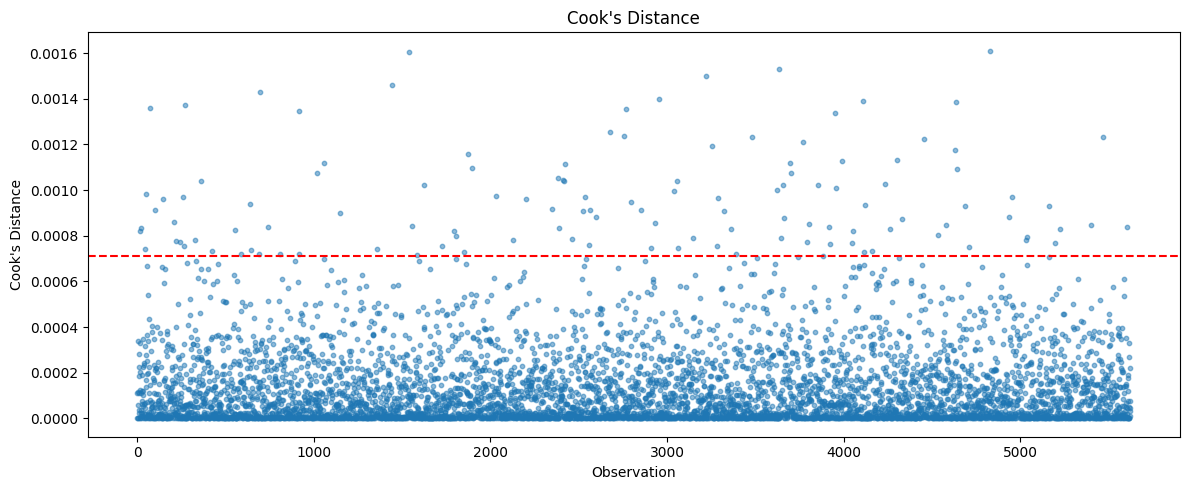

Number with |studentized residual| > 3: 0
Largest absolute studentized residual: 2.9940151406120075


In [ ]:
# Assumption 6: No Influential Outliers

# Create influence measures
influence = OLSInfluence(ols_model)

# 1. Cook's Distance
cooks_d = influence.cooks_distance[0]

# Common threshold
cooks_threshold = 4 / len(X_train)

print(f"Cook's Distance threshold: {cooks_threshold:.6f}")
print(f"Number above threshold: {(cooks_d > cooks_threshold).sum()}")
print(f"Maximum Cook's Distance: {cooks_d.max():.3f}")


# Cook's Distance plot
plt.figure(figsize=(12, 5))

plt.scatter(
    np.arange(len(cooks_d)),
    cooks_d,
    s=10,
    alpha=0.5
)

plt.axhline(
    cooks_threshold,
    color="red",
    linestyle="--"
)

plt.xlabel("Observation")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance")

plt.tight_layout()
plt.show()


# 2. Studentized Residuals
studentized_residuals = influence.resid_studentized_external

print(
    "Number with |studentized residual| > 3:",
    (np.abs(studentized_residuals) > 3).sum()
)

print(
    "Largest absolute studentized residual:",
    np.max(np.abs(studentized_residuals))
)

In [ ]:
# No influential outliers assumption is confirmed
Maximum Cook's Distance was 0.002, indicating no highly influential observations.
No studentized residuals exceeded ±3.

# **Predictions for Churn**

In [ ]:
# Classification-style performance for Linear Regression

# Convert predictions into churn / no churn using 0.50 cutoff
lr_class = (lr_pred >= 0.50).astype(int)

accuracy = accuracy_score(y_test, lr_class)
precision = precision_score(y_test, lr_class, zero_division=0)
recall = recall_score(y_test, lr_class, zero_division=0)
f1 = f1_score(y_test, lr_class, zero_division=0)

print(f"Accuracy: {accuracy * 100:.1f}%")
print(f"Precision: {precision * 100:.1f}%")
print(f"Recall: {recall * 100:.1f}%")
print(f"F1 Score: {f1:.3f}")

Accuracy: 79.5%
Precision: 63.8%
Recall: 53.2%
F1 Score: 0.580


In [ ]:
# Linear Regression Overall Conclusion

Accuracy: **79.5%**

Assumptions confirmed:
- Independence
- No influential outliers

Assumptions not confirmed:
- Linearity
- Homoscedasticity
- Normality of residuals
- No multicollinearity

Although linear regression had 79.5% accuracy, 4 of the 6 assumptions were not confirmed. This suggests linear regression is not the best model for predicting customer churn.

# Linear Regression Limitation

Linear regression is not ideal for churn because churn is binary, while linear regression can produce predicted probabilities below 0 or above 1. In this model, 15.6% of predictions fell outside the 0–1 range

In [ ]:
Accuracy: **79.5%**
Precision: **63.8%**
Recall: **53.2%**
F1 Score: **0.580**